In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pingouin as pg
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import math
import seaborn as sns
import random
import pickle

## Part 1. GWAS info collection for zebrafish GWAS candidate genes

In [45]:
df_mapped_zebrafish_gene = pd.read_pickle('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/zebrafish2human/processed_data/GWAS_candidate_genes_20260113.pkl')
df_mapped_zebrafish_gene.head()

,QTL_id,Peak_SNP_x,Mapped_genes,Trait,r2,ZFIN ID,zebrafish_symbol,zebrafish_ens,ZFIN Name,human_symbol,...,QTL_no,block_start,block_end,block_size,gene_start,gene_end,gene_strand,3,4,6
0,1:13180420|T4_TDEN,1:13180420,eif3bb,T4_TDEN,0.5,ZDB-GENE-090312-175,eif3bb,ENSDARG00000074213,"eukaryotic translation initiation factor 3, su...",EIF3B,...,1,11690229,13439814,1749585,0,0,0,11690360,11707665,+
1,1:13180420|T4_TDEN,1:13180420,si:dkey-26i13.8,T4_TDEN,0.5,NaN,NaN,NaN,NaN,NaN,...,1,11690229,13439814,1749585,0,0,0,11711226,11733130,+
2,1:13180420|T4_TDEN,1:13180420,chst12b.1,T4_TDEN,0.5,ZDB-GENE-090312-144,chst12b.1,ENSDARG00000077198,"carbohydrate sulfotransferase 12b, tandem dupl...",CHST12,...,1,11690229,13439814,1749585,0,0,0,11736420,11737595,+
3,1:13180420|T4_TDEN,1:13180420,ttyh3b,T4_TDEN,0.5,ZDB-GENE-051120-105,ttyh3b,ENSDARG00000007678,tweety family member 3b,TTYH3,...,1,11690229,13439814,1749585,0,0,0,11781544,11850353,-
4,1:13180420|T4_TDEN,1:13180420,iqce,T4_TDEN,0.5,ZDB-GENE-090312-217,iqce,ENSDARG00000089930,IQ motif containing E,IQCE,...,1,11690229,13439814,1749585,0,0,0,11854710,11878845,-


In [ ]:
def func1(gene):
    
    def genesymbol2gwas(gene):
        url = "https://www.ebi.ac.uk/gwas/api/search/downloads?q=ensemblMappedGenes:{}&pvalfilter=&orfilter=&betafilter=&datefilter=&genomicfilter=&genotypingfilter[]=&traitfilter[]=&dateaddedfilter=&facet=association&efo=true"
        df_temp = pd.read_csv(url.format(gene), sep='\t')
        condition1 = df_temp['MAPPED_GENE'].str.count(gene+'-')==0
        condition2 = df_temp['MAPPED_GENE'].str.count(gene)>=1
        condition3 = df_temp['MAPPED_GENE'].str.count(gene+'-')>0
        condition4 = df_temp['MAPPED_GENE'].str.count(gene)>1
        df_temp_sub1 = df_temp.loc[(condition1&condition2)]
        df_temp_sub2 = df_temp.loc[(condition3&condition4)]
        df_filtered = pd.concat((df_temp_sub1, df_temp_sub2))
        return df_filtered

    def subfunc1(x):
        z = []
        for y in x.split(','):
            y=y.split('/')[-1]
            if y not in z:
                z.append(y)
        return z
    
    def flatten(l):
        return [item for sublist in l for item in sublist]
    
    df = genesymbol2gwas(gene)
    
    efolist = list(df['MAPPED_TRAIT_URI'].dropna().apply(lambda x: subfunc1(x)))
    annotationlist = df['MAPPED_TRAIT'].values.tolist()
    return [list(set(flatten(efolist))), annotationlist]

df_temp = df_mapped_zebrafish_gene.loc[:,['zebrafish_symbol', 'human_symbol']].drop_duplicates('human_symbol')
df_temp = df_temp.dropna(subset=['human_symbol'])
df_temp['gwas_info'] = df_temp['human_symbol'].apply(lambda x: func1(x))
df_temp.head()

In [ ]:
df_mapped_zebrafish_gene = pd.merge(df_mapped_zebrafish_gene, df_temp[['zebrafish_symbol', 'gwas_info']], on='zebrafish_symbol', how='left')
df_mapped_zebrafish_gene['Mapped_human_gwas_traits'] = df_mapped_zebrafish_gene['gwas_info'].str[1]
df_mapped_zebrafish_gene['Mapped_human_gwas_traits_efo'] = df_mapped_zebrafish_gene['gwas_info'].str[0]
df_mapped_zebrafish_gene = df_mapped_zebrafish_gene.dropna(subset=['human_ens'])
df_mapped_zebrafish_gene = df_mapped_zebrafish_gene.dropna(subset=['Mapped_human_gwas_traits_efo'])

In [9]:
wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/hGWAS/'
df_human_gwas_cat = pd.read_csv(wdir+'gwas_catalog_v1.0.2-associations_e114_r2025-05-13.tsv',
                sep='\t')
df_human_gwas_cat = df_human_gwas_cat.dropna(subset=['MAPPED_TRAIT_URI'])
df_human_gwas_cat.head()

/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_24087/3151208298.py:2: DtypeWarning: Columns (9,11,12,13,23,26,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_human_gwas_cat = pd.read_csv(wdir+'gwas_catalog_v1.0.2-associations_e114_r2025-05-13.tsv',


,DATE ADDED TO CATALOG,PUBMEDID,FIRST AUTHOR,DATE,JOURNAL,LINK,STUDY,DISEASE/TRAIT,INITIAL SAMPLE SIZE,REPLICATION SAMPLE SIZE,...,PVALUE_MLOG,P-VALUE (TEXT),OR or BETA,95% CI (TEXT),PLATFORM [SNPS PASSING QC],CNV,MAPPED_TRAIT,MAPPED_TRAIT_URI,STUDY ACCESSION,GENOTYPING TECHNOLOGY
0,2020-08-03,32352494,Han X,2020-04-30,JAMA Ophthalmol,www.ncbi.nlm.nih.gov/pubmed/32352494,Association of Myopia and Intraocular Pressure...,Spherical equivalent,"95,827 European ancestry individuals",NaN,...,7.698970,NaN,0.07,[0.05-0.09] unit increase,NR [NR],N,refractive error,http://purl.obolibrary.org/obo/MONDO_0004892,GCST010378,Genome-wide genotyping array
1,2020-08-03,32352494,Han X,2020-04-30,JAMA Ophthalmol,www.ncbi.nlm.nih.gov/pubmed/32352494,Association of Myopia and Intraocular Pressure...,Retinal detachment,"4,257 European ancestry cases, 39,181 European...",NaN,...,15.000000,NaN,0.20,[0.16-0.24] unit decrease,NR [NR],N,retinal detachment,http://www.ebi.ac.uk/efo/EFO_0005773,GCST010377,Genome-wide genotyping array
2,2020-08-03,32352494,Han X,2020-04-30,JAMA Ophthalmol,www.ncbi.nlm.nih.gov/pubmed/32352494,Association of Myopia and Intraocular Pressure...,Spherical equivalent,"95,827 European ancestry individuals",NaN,...,15.301030,NaN,0.11,[0.09-0.13] unit increase,NR [NR],N,refractive error,http://purl.obolibrary.org/obo/MONDO_0004892,GCST010378,Genome-wide genotyping array
3,2020-08-03,32352494,Han X,2020-04-30,JAMA Ophthalmol,www.ncbi.nlm.nih.gov/pubmed/32352494,Association of Myopia and Intraocular Pressure...,Spherical equivalent,"95,827 European ancestry individuals",NaN,...,9.221849,NaN,0.20,[0.14-0.26] unit increase,NR [NR],N,refractive error,http://purl.obolibrary.org/obo/MONDO_0004892,GCST010378,Genome-wide genotyping array
4,2020-08-03,32352494,Han X,2020-04-30,JAMA Ophthalmol,www.ncbi.nlm.nih.gov/pubmed/32352494,Association of Myopia and Intraocular Pressure...,Spherical equivalent,"95,827 European ancestry individuals",NaN,...,9.522879,NaN,0.08,[0.06-0.1] unit increase,NR [NR],N,refractive error,http://purl.obolibrary.org/obo/MONDO_0004892,GCST010378,Genome-wide genotyping array


In [11]:
df_human_gwas_efo = pd.read_csv(wdir+'gwas_catalog_trait-mappings_r2025-05-13.tsv',sep='\t')
df_human_gwas_efo.head()

,Disease trait,EFO term,EFO URI,Parent term,Parent URI
0,Cervical cancer,cervical cancer,http://purl.obolibrary.org/obo/MONDO_0002974,Cancer,http://www.ebi.ac.uk/efo/EFO_0000616
1,Cervical cancer (PheCode 180.1),cervical cancer,http://purl.obolibrary.org/obo/MONDO_0002974,Cancer,http://www.ebi.ac.uk/efo/EFO_0000616
2,Cervical cancer and dysplasia (PheCode 180),cervical cancer,http://purl.obolibrary.org/obo/MONDO_0002974,Cancer,http://www.ebi.ac.uk/efo/EFO_0000616
3,Cervical dysplasia or cervical cancer (MTAG),cervical cancer,http://purl.obolibrary.org/obo/MONDO_0002974,Cancer,http://www.ebi.ac.uk/efo/EFO_0000616
4,Phosphatidylcholine (16:0_0:0) levels,level of Phosphatidylcholine (16:0_0:0) in blo...,http://purl.obolibrary.org/obo/OBA_2045066,Other measurement,http://www.ebi.ac.uk/efo/EFO_0001444


## Part 2. GWAS trait enrichment analysis

In [14]:
wdir='/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/zebrafish2human/processed_data/'
df_mapped_zebrafish_gene = pd.read_pickle(wdir+'GWAS_candidate_human_ortho_efo_v1.pkl')

In [16]:
## get a list of all the EFOs mapped by zebrafish candidate genes
gene_num_list = []
gene_list = []
efo_list = list(set(df_mapped_zebrafish_gene['Mapped_human_gwas_traits_efo'].sum()))
for efo in efo_list:
    df = df_mapped_zebrafish_gene.loc[df_mapped_zebrafish_gene['Mapped_human_gwas_traits_efo'].apply(lambda x:efo in x)]
    gene_num = df.shape[0]
    gene_list.append(list(df['human_symbol'].unique()))
    gene_num_list.append(gene_num)
df_efo_count = pd.DataFrame({'EFO':efo_list, 'Gene_num':gene_num_list, 'H_genes':gene_list})

## develop a function to get annotation information for each efo from the above matrix
def EFO_annotation(efo):
    efoterm = df_human_gwas_efo.loc[df_human_gwas_efo['EFO URI'].str.split("/").str[-1]==efo]['EFO term'].unique()
    if len(efoterm)>0:
        return [efoterm[0]]
    #def list_index(target_list, efo):
        #target_list = target_list.split(',')
        #for i, s in enumerate(target_list):
            #if efo in s:
                #return i
    #def get_trait(trait_list, index):
        #return trait_list.split(",")[index]
    #df_temp = df_human_gwas_cat.loc[df_human_gwas_cat['MAPPED_TRAIT_URI'].str.contains(efo)][['MAPPED_TRAIT_URI', 'MAPPED_TRAIT']].drop_duplicates()
    #if df_temp.shape[0]>0:
        #df_temp['trait_index'] = df_temp['MAPPED_TRAIT_URI'].apply(lambda x: list_index(x, efo)) 
        #annotation = df_temp.apply(lambda x: get_trait(x.MAPPED_TRAIT, x.trait_index),axis=1).str.strip().drop_duplicates()
        #annotation = list(set(annotation.str.cat(sep=',').split(',')))
        #return annotation

df_efo_count['annotation'] = df_efo_count['EFO'].apply(lambda x: EFO_annotation(x))
df_efo_count

,EFO,Gene_num,H_genes,annotation
0,EFO_0020097,2,[DPYSL5],[QRS-T angle]
1,EFO_0005091,25,"[XPO1, AKT3, KIRREL1, SDHC, MPZ, CAPN10, GMIP,...",[monocyte count]
2,OBA_2055565,1,[CHGB],[CHGB/RTBDN protein level ratio in blood]
3,EFO_0004536,13,"[SNX8, PCDH10, XPO1, SDHC, MPZ, IQGAP2, CENPH,...",[total blood protein measurement]
4,OBA_2040179,12,"[YDJC, UBE2L3, POLK, MIER3, SULF2, MAFB, IQSEC...",[level of phosphatidylcholine]
...,...,...,...,...
2120,OBA_2053346,1,[SSBP3],[CD69/EDAR protein level ratio in blood]
2121,EFO_0008022,1,[USP34],[angiogenin measurement]
2122,EFO_0009260,9,"[MYO15A, PHF20, NDRG3, TRPC4AP, MYH7B, GRIA3, ...",[non-melanoma skin carcinoma]
2123,OBA_2055469,2,[PDLIM7],[ITGB1BP2/PDLIM7 protein level ratio in blood]


In [18]:
##develop a function to summarize human genes associated with efo belonging to a specific category
def func1(df_efo_count, trait_category):
    
    pyd = pd.read_excel('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/hGWAS/GWAS_traits_categorization_20251203.xlsx',
                       header=None, sheet_name=trait_category)
    pyd = pd.Series(pyd[0].apply(lambda x: [x]))
    pyd_mapped = df_efo_count.loc[df_efo_count.set_index('annotation').index.isin(pyd)]
    pyd_mapped = pyd_mapped[['annotation', 'Gene_num', 'H_genes','EFO']]
    pyd_mapped = pyd_mapped.sort_values('Gene_num',ascending=False)
    pyd_mapped.rename(columns = {'annotation':'Pyschiatric_disease'}, inplace=True)

    pyd_unmapped = pyd.loc[~pyd.isin(pyd_mapped['Pyschiatric_disease'])].reset_index()
    pyd_unmapped['Gene_num'] = 0
    pyd_unmapped['H_genes'] = np.nan
    pyd_unmapped = pyd_unmapped.iloc[:, 1:]
    pyd_unmapped.columns = ['Pyschiatric_disease', 'Gene_num', 'H_genes']
    
    df_res_pyd = pd.concat((pyd_mapped, pyd_unmapped))
    
    #df_temp = df_human_gwas_efo.loc[df_human_gwas_efo['EFO term'].isin(df_res_pyd['Pyschiatric_disease'].apply(lambda x: x[0]))][['EFO term', 'EFO URI']].drop_duplicates()
    df_temp = df_human_gwas_cat.loc[df_human_gwas_cat['MAPPED_TRAIT'].isin(df_res_pyd['Pyschiatric_disease'].apply(lambda x: x[0]))][['MAPPED_TRAIT','MAPPED_TRAIT_URI']].drop_duplicates()

    df_temp['EFO'] = df_temp['MAPPED_TRAIT_URI'].str.split('/').str[-1]
    df_res_pyd.index = df_res_pyd['Pyschiatric_disease'].str[0]
    df_temp = df_temp.set_index('MAPPED_TRAIT')
    del df_res_pyd['EFO']
    df_res_pyd = pd.concat([df_res_pyd,df_temp['EFO']],axis=1).dropna(subset = ['EFO'])
    df_res_pyd = df_res_pyd.loc[df_res_pyd['EFO'].isin(df_human_gwas_efo['EFO URI'].str.split('/').str[-1].unique())]
    return df_res_pyd

In [20]:
#count number of genes associated with a given disease
def func_efo_total(EFO_number):
    ori_gene_list = df_human_gwas_cat.loc[df_human_gwas_cat['MAPPED_TRAIT_URI'].str.contains(EFO_number)]['MAPPED_GENE'].drop_duplicates()
    if len(ori_gene_list)>0:

        ori_gene_list2 = ori_gene_list.loc[ori_gene_list.str.contains(' - ')==False]
        if len(ori_gene_list2)>0:
            new_gene_list2 = []
            for element in list(set(ori_gene_list2.apply(pd.Series).stack().to_list())):
                if ', ' in element:
                    element = list(set(element.split(', ')))
                else:
                    element = [element]
                new_gene_list2 += element
        else:
            new_gene_list2 = []

        ori_gene_list1 = ori_gene_list.loc[ori_gene_list.str.contains(' - ')==True]
        if len(ori_gene_list1)>0:
            new_gene_list1 = set(ori_gene_list1.str.split(' - ').apply(pd.Series).stack().to_list())
            new_gene_list = set(new_gene_list1 | set(new_gene_list2))
        else:
            new_gene_list = set(new_gene_list2)

        return new_gene_list.intersection(set(df_human_ortho['human_symbol']))
    else:
        return '[]'

### GWAS enrichment analysis at individual trait/disease level

In [23]:
##number of all human genes with zebrafish orthologues
df_human_ortho = pd.read_excel('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/ZebrafishGenomeAnnotation/ortho_genes_20250227.xlsx', sheet_name = 'human_orthos')

##important !! using not all human genes but only those orthologous to zebrafish genes for enrichment analysis
tnum_gene = df_human_ortho['human_symbol'].drop_duplicates().dropna().shape[0]
znum_gene = 371
df_efo_psy = func1(df_efo_count, 'psychiatric_disorder')
df_efo_psy = df_efo_psy.dropna(subset=['H_genes'])
df_efo_psy['Gene_num'] = df_efo_psy['H_genes'].apply(lambda x: len(set(x)))
df_efo_psy['total_gene_list'] = df_efo_psy['EFO'].astype(str).apply(lambda x: func_efo_total(x) if x != 'nan' else x)
df_efo_psy['total_gene_list'] = (df_efo_psy['H_genes']+df_efo_psy['total_gene_list'].apply(lambda x: list(x))).apply(lambda x: set(x))
df_efo_psy['total_gene'] = df_efo_psy['total_gene_list'].apply(lambda x : len(x))
df_efo_psy['ratio_gwas'] = df_efo_psy['Gene_num']/znum_gene
df_efo_psy['ratio_all']  = df_efo_psy['total_gene'].apply(lambda x: x/tnum_gene if x != 'nan' else x)

from scipy.stats import fisher_exact
def func_fisher(num1, num2,tnum_gene,znum_gene):
    #num1 is the number of candidate hgwas genes associated with the disease
    #num2 is the number of total hgwas genes associated with the disease
    #num2-num1 is the number of non-candidate hgwas genes associated with the disease
    num3 = num2-num1
    table = np.array([[num1,num3], [znum_gene-num1, tnum_gene-znum_gene-num3]])
    res = fisher_exact(table, alternative='two-sided')
    return res[1]
df_efo_psy['p-value'] = df_efo_psy.apply(lambda x: func_fisher(x['Gene_num'], x['total_gene'],tnum_gene,znum_gene), axis=1)
df_efo_psy = df_efo_psy.sort_values('p-value')
df_efo_psy.loc[df_efo_psy['p-value']<=0.05]

,Pyschiatric_disease,Gene_num,H_genes,EFO,total_gene_list,total_gene,ratio_gwas,ratio_all,p-value
substance-related disorder,[substance-related disorder],9,"[XPO1, EIF2B3, MYO15A, RPS6KA4, ERCC8, ELOVL7,...",MONDO_0002494,"{RABEPK, GCKR, ABT1, SEMA6D, USP4, FTO, HPCAL4...",42,0.024259,0.003084,0.000002
Alzheimer disease,[Alzheimer disease],43,"[CHST12, SNX8, SLC24A2, TMOD1, B3GNT2, COMMD1,...",MONDO_0004975,"{SLMAP, FOXE1, BCAM, CACNA1A, NBEAL1, KDM5B, E...",955,0.115903,0.070133,0.001258
generalized anxiety disorder,[generalized anxiety disorder],5,"[GNE, CLTA, LHX8, FAM120A, LRFN5]",EFO_1001892,"{FRAS1, MAD1L1, MGMT, LAMC3, FAM120A, TLCD4, I...",31,0.013477,0.002277,0.001385
post-traumatic stress disorder,[post-traumatic stress disorder],8,"[AKT3, NOS1, IPO9, MON1B, KAZN, PHF2, FAM120A,...",EFO_0001358,"{LHX2, KAZN, EGR3, ANAPC4, MAD1L1, ZMAT3, GABB...",89,0.021563,0.006536,0.002914
mood disorder,[mood disorder],8,"[SLC24A2, SV2C, SLC44A5, LMOD1, KAZN, PHF2, KL...",EFO_0004247,"{ADAMTS6, KAZN, CUL3, MYO1H, ZNF507, MAD1L1, R...",124,0.021563,0.009106,0.020124
stress-related disorder,[stress-related disorder],2,"[EDIL3, LRFN5]",EFO_0010098,"{SDK1, PDE4B, EDIL3, CNGB3, ADCY2, RAD51, LRFN...",9,0.005391,0.000661,0.023480


### GWAS enrichment analysis at the level of trait cateogories

In [30]:
df_cat_gwas_enrich = {}
##compute the total number of human orthologues relative to zebrafish as tnum_gene
tnum_gene = df_human_ortho['human_symbol'].drop_duplicates().dropna().shape[0]
##compute the total number of queried human orthologues relative to zebrafish as znum_gene
znum_gene = 371
for cat in ['behavior','mental_process','psychiatric_disorder','neurodegenerative_disease','immune_system_disorder','musculoskeletal','digestive_system_disease']:

    df_efo = func1(df_efo_count, cat)
    df_efo = df_efo.dropna(subset=['H_genes'])
    df_efo['Gene_num'] = df_efo['H_genes'].apply(lambda x: len(set(x)))
    df_efo['total_gene_list'] = df_efo['EFO'].astype(str).apply(lambda x: func_efo_total(x) if x != 'nan' else x)
    df_efo['total_gene'] = df_efo['total_gene_list'].apply(lambda x : len(x))
    df_efo['ratio_gwas'] = df_efo['Gene_num']/znum_gene
    df_efo['ratio_all']  = df_efo['total_gene'].apply(lambda x: x/tnum_gene if x != 'nan' else x)
    
    from scipy.stats import fisher_exact
    def func_fisher(num1, num2,tnum_gene,znum_gene):
        #num1 is the number of candidate hgwas genes associated with the disease
        #num2 is the number of total hgwas genes associated with the disease
        #num2-num1 is the number of non-candidate hgwas genes associated with the disease
        num3 = num2-num1
        table = np.array([[num1,num3], [znum_gene-num1, tnum_gene-znum_gene-num3]])
        res = fisher_exact(table, alternative='two-sided')
        return res[1]
        
    df_cat_gwas_enrich.update({cat:category_enrichemnt(df_efo)})
    
df_cat_gwas_enrich = pd.DataFrame(df_cat_gwas_enrich)
df_cat_gwas_enrich = df_cat_gwas_enrich.transpose()
df_cat_gwas_enrich.columns = ['zgwas_gene', 'zgwas_gene_no', 'total_hgwas_gene', 'total_hgwas_gene_no', 'p_enrich']
df_cat_gwas_enrich = df_cat_gwas_enrich.sort_values('p_enrich')
df_cat_gwas_enrich

,zgwas_gene,zgwas_gene_no,total_hgwas_gene,total_hgwas_gene_no,p_enrich
psychiatric_disorder,"[KAZN, MLIP, FRMPD3, SMIM15, VGLL4, PLA2G12A, ...",158,"[RASD1, IMMP1L, KLF10, TRIP12, KRI1, SCG3, CCR...",4507,0.00011
mental_process,"[ALPL, TOP1, NUP210, INO80, SNX8, MGST2, TMEM1...",65,"[RPRML, DNAL4, SCG3, NCOA6, CACNA1D, ATRNL1, T...",1791,0.015467
neurodegenerative_disease,"[ALPL, ZBTB25, KAZN, EIF4G3, TOP1, SNX8, PUS10...",52,"[EGFL6, CCR4, CUEDC1, ZSWIM2, CHRNA6, ST18, FR...",1460,0.041091
musculoskeletal,"[KCNAB1, BMP5, KAZN, MLIP, VGLL4, PUS10, TMOD1...",96,"[TP53, CNGA1, C1orf146, KLF10, ANKS1A, MFN1, C...",3030,0.099612
behavior,"[FAM83B, GMIP, KAZN, EDIL3, PCDH18, ANXA5, EIF...",65,"[ANKS1A, CHD9, NCOA6, CACNA1D, DNAJC11, ATRNL1...",2057,0.186115
digestive_system_disease,"[BMP5, KAZN, MLIP, ANXA5, FRMPD3, PUS10, ARHGA...",99,"[TP53, SAYSD1, GINS2, CCR4, DUSP4, LTBP3, CSK,...",3353,0.359441
immune_system_disorder,"[KCNAB1, GLIS1, FERMT1, EDIL3, MLIP, YDJC, NUP...",63,"[EGFL6, C1orf146, ANKS1A, CCR4, CHD9, CSK, CUE...",2183,0.615482


/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_24087/88395826.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g=sns.barplot(df_plot['p_enrich'].apply(lambda x: math.log(x,10)*(-1)),legend=False, orient="y", palette = [disease_color[disease] for disease in df_plot.index])


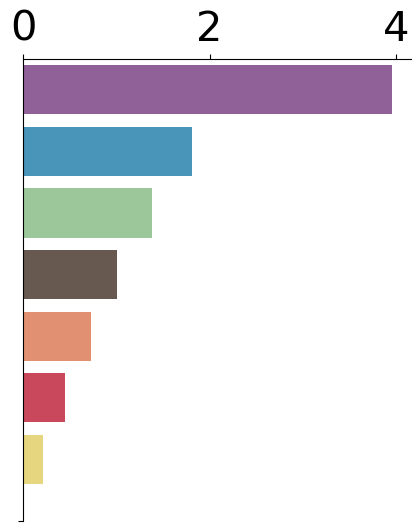

In [32]:
##setup color for each disease category
disease_color = {'psychiatric_disorder':"#9656a2", "mental_process":'#369acc',
                 'neurodegenerative_disease':'#95cf92', 'behavior':'#f4895f', 'immune_system_disorder':'#f8e16f',
                'digestive_system_disease':"#de324c",'musculoskeletal':'#6c584c'}
df_plot = df_cat_gwas_enrich
f, ax = plt.subplots(1,1, figsize=(5,6))
g=sns.barplot(df_plot['p_enrich'].apply(lambda x: math.log(x,10)*(-1)),legend=False, orient="y", palette = [disease_color[disease] for disease in df_plot.index])
g.set_yticklabels('')
g.set_xlabel('')
g.set_xticks(np.arange(0,5,2))
g.set_xticklabels(np.arange(0,5,2), fontsize=30)
g.set_facecolor('white')
g.xaxis.tick_top()
g.spines['top'].set_visible(True)
g.spines['bottom'].set_visible(False)
g.spines['right'].set_visible(False)
g.set_yticks('')
plt.show()

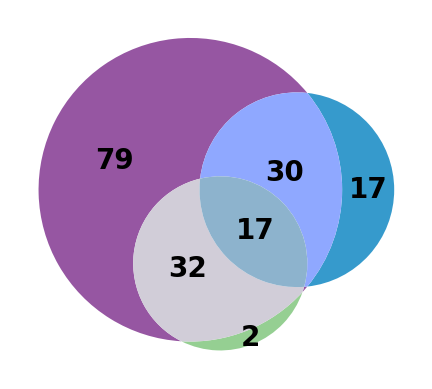

In [34]:
from matplotlib_venn import venn3, venn3_circles
disease_dic = {
    'psy':set(df_cat_gwas_enrich.loc['psychiatric_disorder'].zgwas_gene),
    'mental_process':set(df_cat_gwas_enrich.loc['mental_process'].zgwas_gene),
    'neurodegenerative_disease':set(df_cat_gwas_enrich.loc['neurodegenerative_disease'].zgwas_gene),
}
v=venn3(list(disease_dic.values()), list(disease_dic.keys()), set_colors=["#9656a2", '#369acc', "#95cf92"], 
        alpha=1)
for text in v.subset_labels:
    if text is not None: # Check if the label exists (some areas might be empty)
        text.set_fontweight('bold')
        text.set_fontsize(20)
for label in v.set_labels:
    if label is not None:
        label.set_visible(False)
plt.show()

In [28]:
def category_enrichemnt(df_efo_cat):
    #df_efo_cat=df_efo_cat.loc[df_efo_cat['Gene_num']>4]
    from itertools import chain
    zgwas_list = []
    total_list = []
    for H_genes in df_efo_cat.dropna()['H_genes']:
        zgwas_list.append(set(H_genes))
    for genelists in df_efo_cat['total_gene_list']:
        total_list.append(genelists)
    all_zgwas_gene = list(set(chain.from_iterable(zgwas_list)))
    all_hgwas_gene = list(set(chain.from_iterable(total_list)))
    all_hgwas_gene = list(set(all_hgwas_gene+all_zgwas_gene))
    zgwas_num = len(all_zgwas_gene)
    hgwas_num = len(all_hgwas_gene)
    return [all_zgwas_gene, zgwas_num, all_hgwas_gene, hgwas_num, func_fisher(zgwas_num, hgwas_num,tnum_gene,znum_gene)]

In [245]:
df_output = df_cat_gwas_enrich.copy().iloc[:, [1,3,4,0,2]]
df_output.rename(columns = {'zgwas_gene_no':'zgwas_gene_pos_no', 
                            'total_hgwas_gene_no':'bg_gwas_gene_pos_no',
                           'p_enrich':'pvalue', 
                           'zgwas_gene':'zgwas_gene_pos_list',
                           'total_hgwas_gene':'bg_gwas_gene_pos_list'}, inplace=True)
df_output['zgwas_gene_total'] = 371
df_output['zgwas_gene_neg_no'] = df_output['zgwas_gene_total']-df_output['zgwas_gene_pos_no']
df_output['bg_gwas_gene_total'] = tnum_gene
df_output['bg_gwas_gene_pos_no'] = df_output['bg_gwas_gene_pos_no']-df_output['zgwas_gene_pos_no']
df_output['bg_gwas_gene_neg_no'] = df_output['bg_gwas_gene_total']-df_output['bg_gwas_gene_pos_no']-df_output['zgwas_gene_neg_no']
df_output = df_output[['zgwas_gene_total', 'zgwas_gene_pos_no','zgwas_gene_neg_no', 
                       'bg_gwas_gene_total', 'bg_gwas_gene_pos_no', 'bg_gwas_gene_neg_no',
                      'pvalue','zgwas_gene_pos_list', 'bg_gwas_gene_pos_list']]

output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S3 GWAS catalog enrichment analysis.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_output.to_excel(writer, sheet_name="Summary statistics", index=False)
